# TimesFM: Time Series Forecasting Using Decoder-Only Foundation Model


# TimesFM: a foundation model capable of zero-shot  forecasting. 
# This model is developed based on a decoder-only transformer  architecture, using input patching. 
# The forecasting capabilities of this foundation model are comparable to supervised time series forecasting  models.

# Multivariate use case

In [ ]:
%pip install --upgrade pip


  Using cached pip-25.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install timesfm[torch]

  Using cached timesfm-1.3.0-py3-none-any.whl.metadata (15 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached einshape-1.0-py3-none-any.whl.metadata (706 bytes)
  Using cached huggingface_hub-0.34.4-py3-none-any.whl.metadata (14 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached typer-0.17.4-py3-none-any.whl.metadata (15 kB)
  Using cached utilsforecast-0.2.12-py3-none-any.whl.metadata (7.6 kB)
  Using cached wandb-0.21.4-py3-none-win_amd64.whl.metadata (10 kB)
  Using cached filelock-3.19.1-py3-none-any.whl.metadata (2.1 kB)
  Using cached fsspec-2025.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached PyYAML-6.0.2-cp310-cp310-win_amd64.whl.metadata (2.1 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached InquirerPy-0.3.4-py3-none-any.whl.metadata (8.1 kB)
  Using cached pfzy-0.3.4-py3-none-any.whl.metadata (4.9 kB)

In [19]:
%pip install timesfm[cpu]

Note: you may need to restart the kernel to use updated packages.


In [26]:
pip show timesfm

Name: timesfm
Version: 1.3.0
Summary: Open weights time-series foundation model from Google Research.
Home-page: https://github.com/google-research/timesfm
Author: Rajat Sen
Author-email: senrajat@google.com
License: 
Location: c:\users\della\projects\ai_projects\python310\lib\site-packages
Requires: absl-py, einshape, huggingface_hub, numpy, pandas, scikit-learn, typer, utilsforecast, wandb
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [27]:
%pip install -U timesfm

Note: you may need to restart the kernel to use updated packages.


In [28]:
pip show timesfm

Name: timesfm
Version: 1.3.0
Summary: Open weights time-series foundation model from Google Research.
Home-page: https://github.com/google-research/timesfm
Author: Rajat Sen
Author-email: senrajat@google.com
License: 
Location: c:\users\della\projects\ai_projects\python310\lib\site-packages
Requires: absl-py, einshape, huggingface_hub, numpy, pandas, scikit-learn, typer, utilsforecast, wandb
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [55]:
import pandas as pd

df = pd.read_csv("data/PICK3_225.csv")
print(df.head())

   time  x1  x2  x3
0   225   1   6   3
1   224   0   4   8
2   223   7   2   3
3   222   4   5   2
4   221   3   6   3


In [56]:
print(df.tail())

     time  x1  x2  x3
220     5   0   4   4
221     4   3   0   1
222     3   0   6   1
223     2   0   8   4
224     1   1   7   7


In [6]:
import os
print(os.getcwd())

c:\Users\della\Projects\AI_Projects


In [5]:
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_
percentage_error, r2_score
from collections import defaultdict
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['JAX_PMAP_USE_TENSORSTORE'] = 'false'

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.


ModuleNotFoundError: No module named 'torch'

In [6]:
%pip install jax jaxlib

  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------- -------------------- 1.3/2.7 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 7.5 MB/s  0:00:00
   ---------------------------------------- 0.0/57.9 MB ? eta -:--:--
   - -------------------------------------- 2.1/57.9 MB 11.7 MB/s eta 0:00:05
   --- ------------------------------------ 4.7/57.9 MB 11.4 MB/s eta 0:00:05
   ---- ----------------------------------- 6.8/57.9 MB 11.3 MB/s eta 0:00:05
   ------ --------------------------------- 9.2/57.9 MB 11.4 MB/s eta 0:00:05
   -------- ------------------------------- 11.8/57.9 MB 11.5 MB/s eta 0:00:04
   --------- ------------------------------ 13.9/57.9 MB 11.3 MB/s eta 0:00:04
   ----------- ---------------------------- 16.0/57.9 MB 11.2 MB/s eta 0:00:04
   ------------ --------------------------- 17.8/57.9 MB 10.9 MB/s eta 0:00:04
   ------------- 

In [7]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
     ---------------------------------------- 0.0/536.2 kB ? eta -:--:--
     ---------------------------------------- 536.2/536.2 kB 8.8 MB/s  0:00:00
   ---------------------------------------- 0.0/619.4 MB ? eta -:--:--
   ---------------------------------------- 1.0/619.4 MB 8.4 MB/s eta 0:01:14
   ---------------------------------------- 3.4/619.4 MB 9.6 MB/s eta 0:01:05
   ---------------------------------------- 5.0/619.4 MB 8.9 MB/s eta 0:01:10
   ---------------------------------------- 7.3/619.4 MB 9.6 MB/s eta 0:01:04
    --------------------------------------- 9.4/619.4 MB 10.0 MB/s eta 0:01:02
    --------------------------------------- 12.3/619.4 MB 10.3 MB/s eta 0:01:00
    --------------------------------------- 14.2/619.4 MB 10.5 MB/s eta 0:00:58
   - -------------------------------------- 16.8/619.4 MB 10.5 MB/s eta 0:00:58
   - -------------------------------------- 18.6/619.4 MB 10.5 MB/s eta 0:00:58
   - ----

In [9]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.1 MB 10.7 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 11.4 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 11.2 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------------------------- -- 2.1/2.3 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 9.9 MB/s  0:00:00

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [

In [29]:
import numpy as np
import pandas as pd
import timesfm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from collections import defaultdict
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['JAX_PMAP_USE_TENSORSTORE'] = 'false'

In [57]:

# Assume df is already loaded
df = df.sort_values('time', ascending=True)  # TimesFM expects chronological order

# Features and target
features = ['x1', 'x2', 'x3']
target_time_index = 225  # the first row we want to predict

# Train data: everything except the first row
train_df = df[df['time'] != target_time_index].copy()

# Convert to NumPy arrays
X_train = train_df[features].values
times_train = train_df['time'].values


In [58]:
X_train.shape, times_train.shape

((224, 3), (224,))

# Prepare TimesFM 

In [16]:
pip install timesfm jax jaxlib


Note: you may need to restart the kernel to use updated packages.


In [37]:
%pip install huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [59]:
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="cpu",  # or "cpu"
        context_len=224,
        horizon_len=1,
        input_patch_len=32,
        output_patch_len=128,
        num_layers=20,
        model_dims=1280,
       
    )
    ,
     checkpoint=timesfm.TimesFmCheckpoint(
         huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
     ),
)

Fetching 3 files: 100%|██████████| 3/3 [00:00<?, ?it/s]


In [ ]:
import pandas as pd
import timesfm

# History strictly before time=238
train_df = df[df["time"] < 225].sort_values("time")

# Multivariate values
series = train_df[["x1", "x2", "x3"]].to_numpy()

# Load model with checkpoint defaults
tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="cpu",
        context_len=series.shape[0],  # length of your history
        horizon_len=1                  # predict 1 step
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
    ),
)

import numpy as np

series = train_df[["x1","x2","x3"]].to_numpy()


forecast = tfm.forecast(series)
print(forecast)




Fetching 3 files: 100%|██████████| 3/3 [00:00<?, ?it/s]


(array([[5.739841  ],
       [3.889577  ],
       [2.1552503 ],
       [1.0595636 ],
       [3.1598942 ],
       [3.9914422 ],
       [7.7899723 ],
       [5.9347224 ],
       [3.888015  ],
       [2.3699205 ],
       [3.1598942 ],
       [2.8295417 ],
       [4.6324763 ],
       [1.8480338 ],
       [6.873481  ],
       [2.253481  ],
       [3.1746724 ],
       [5.3606234 ],
       [0.8262009 ],
       [5.8871593 ],
       [5.6925745 ],
       [7.7899723 ],
       [7.475624  ],
       [3.9707115 ],
       [4.7507186 ],
       [4.4581037 ],
       [2.3163095 ],
       [2.534402  ],
       [4.7108393 ],
       [4.3781767 ],
       [1.7507184 ],
       [3.360624  ],
       [4.9317455 ],
       [1.939254  ],
       [2.9675941 ],
       [4.465253  ],
       [4.409056  ],
       [7.245698  ],
       [3.7508767 ],
       [0.78420466],
       [0.78311414],
       [4.997379  ],
       [5.479415  ],
       [1.5388496 ],
       [7.174672  ],
       [5.699176  ],
       [3.7920418 ],
       [3.56

In [61]:
series

array([[1, 7, 7],
       [0, 8, 4],
       [0, 6, 1],
       [3, 0, 1],
       [0, 4, 4],
       [9, 3, 3],
       [7, 8, 8],
       [0, 5, 8],
       [6, 2, 6],
       [0, 3, 3],
       [0, 4, 4],
       [5, 6, 1],
       [9, 3, 4],
       [5, 5, 0],
       [3, 5, 9],
       [1, 4, 2],
       [2, 2, 5],
       [5, 2, 9],
       [5, 0, 0],
       [9, 7, 5],
       [3, 8, 6],
       [7, 8, 8],
       [3, 7, 9],
       [9, 1, 4],
       [5, 8, 3],
       [2, 9, 3],
       [7, 0, 2],
       [5, 3, 2],
       [1, 4, 6],
       [4, 3, 6],
       [2, 5, 0],
       [3, 0, 7],
       [0, 8, 6],
       [3, 5, 0],
       [3, 1, 5],
       [8, 7, 3],
       [0, 8, 5],
       [2, 7, 9],
       [1, 9, 2],
       [0, 3, 0],
       [0, 0, 2],
       [1, 7, 6],
       [7, 2, 9],
       [0, 4, 1],
       [6, 6, 9],
       [8, 4, 6],
       [1, 8, 3],
       [2, 8, 2],
       [0, 3, 9],
       [7, 2, 4],
       [1, 6, 2],
       [7, 1, 1],
       [7, 4, 5],
       [1, 0, 9],
       [1, 4, 2],
       [8,

In [69]:
samples, metadata = tfm.forecast(series)

print("samples.shape =", samples.shape)


samples.shape = (224, 1)


In [72]:
def forecast_one(series):
    samples, _ = tfm.forecast(series)
    print("Shape:", samples.shape)

    if samples.ndim == 3:  # (context, horizon, num_samples)
        forecast_mean = samples.mean(axis=-1)   # → (context, horizon)
        return forecast_mean[-1, 0]
    elif samples.ndim == 2:  # (context, num_samples)
        forecast_mean = samples.mean(axis=-1)   # → (context,)
        return forecast_mean[-1]
    elif samples.ndim == 1:  # (context,)
        return samples[-1]
    else:
        raise ValueError(f"Unexpected shape: {samples.shape}")


In [75]:
preds = []
for col in ["x1", "x2", "x3"]:
    series = train_df[[col]].to_numpy()
    pred = forecast_one(series)
    preds.append(round(pred))

preds = np.array([preds])   # shape (1, 3)
print("Predicted [x1, x2, x3] =", preds)


Shape: (224, 1)
Shape: (224, 1)
Shape: (224, 1)
Predicted [x1, x2, x3] = [[0 4 8]]


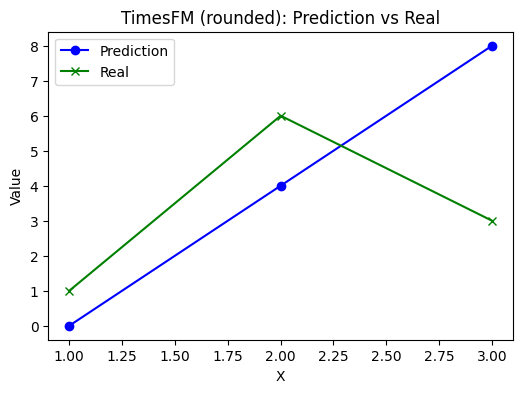

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose forecast gives us 3 predicted values:
Y_pred =np.array([preds[0, 0],   preds[0, 1], preds[0, 2]])
                
#forecast.values().flatten()   # shape (3,)
#Y_pred = np.round(Y_pred).astype(int)
X = np.array([1, 2, 3])
Y_true = np.array([1, 6, 3])           # your linear graph

plt.figure(figsize=(6,4))

# Plot prediction line
plt.plot(X, Y_pred, label="Prediction", marker="o", color="blue")

# Plot reference line
plt.plot(X, Y_true, label="Real", marker="x", color="green")

# # Check coincidences
# for x, yp, yt in zip(X, Y_pred, Y_true):
#     if np.isclose(yp, yt):  # if equal (can use tolerance if float)
#         plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)
# Highlight coincidences with red circles
for x, yp, yt in zip(X, Y_pred, Y_true):
    if yp == yt:
        plt.scatter(x, yp, s=200, facecolors='none', edgecolors='red', linewidths=2)

plt.xlabel("X")
plt.ylabel("Value")
plt.legend()
plt.title("TimesFM (rounded): Prediction vs Real")
plt.show()